In [1]:
import torch
import faiss
import numpy as np
import wikipediaapi

from PIL import Image
from sentence_transformers import SentenceTransformer
from transformers import (
    BlipProcessor,
    BlipForQuestionAnswering,
    AutoTokenizer,
    AutoModelForSeq2SeqLM
)

In [2]:
vision_processor = BlipProcessor.from_pretrained(
    "Salesforce/blip-vqa-base"
)

vision_model = BlipForQuestionAnswering.from_pretrained(
    "Salesforce/blip-vqa-base"
)

embedding_model = SentenceTransformer(
    "sentence-transformers/all-MiniLM-L6-v2"
)

generator_name = "google/flan-t5-base"

tokenizer = AutoTokenizer.from_pretrained(generator_name)

generator_model = AutoModelForSeq2SeqLM.from_pretrained(
    generator_name
)

Loading weights:   0%|          | 0/788 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


In [3]:
wiki = wikipediaapi.Wikipedia(
    language="en",
    user_agent="KnowledgeAugmentedVQA/0.1 (contact: maazmustafa2692@gmail.com)"
)

In [4]:
def chunk_text(text, chunk_size=120, overlap=30):
    words = text.split()
    chunks = []

    start = 0

    while start < len(words):
        end = start + chunk_size

        chunk = " ".join(words[start:end])

        chunks.append(chunk)

        start += chunk_size - overlap

    return chunks

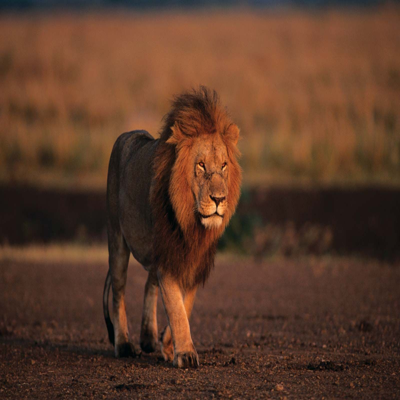

In [41]:
image = Image.open("../data/test.jpg").convert("RGB")
display(image.resize((400, 400)))

In [42]:
identification_question = "What animal is this?"

vision_inputs = vision_processor(
    image,
    identification_question,
    return_tensors="pt"
)

with torch.no_grad():
    vision_output = vision_model.generate(**vision_inputs)

subject = vision_processor.decode(
    vision_output[0],
    skip_special_tokens=True
)

print("Detected subject:", subject)

Detected subject: lion


In [43]:
page = wiki.page(subject)

In [44]:
if not page.exists():
    raise ValueError(f"No Wikipedia article found for: {subject}")

print("Wikipedia page:", page.title)

Wikipedia page: Lion


In [45]:
wikipedia_text = page.text

In [46]:
chunks = chunk_text(wikipedia_text)

chunk_embeddings = embedding_model.encode(
    chunks,
    normalize_embeddings=True
)

In [47]:
dimension = chunk_embeddings.shape[1]

index = faiss.IndexFlatIP(dimension)

index.add(
    np.array(chunk_embeddings).astype("float32")
)

print("Wikipedia chunks indexed:", index.ntotal)

Wikipedia chunks indexed: 95


In [48]:
user_question = "What does this animal eat?"

In [49]:
retrieval_query = f"""
The image contains a {subject}.
{user_question}
"""

In [50]:
query_embedding = embedding_model.encode(
    [retrieval_query],
    normalize_embeddings=True
)

In [51]:
scores, indices = index.search(
    np.array(query_embedding).astype("float32"),
    k=3
)

In [52]:
retrieved_chunks = [
    chunks[idx]
    for idx in indices[0]
]

context = "\n\n".join(retrieved_chunks)
print("Retrieved context:", context)

Retrieved context: the others and mates more frequently. Hunting and diet The lion is a generalist hypercarnivore and is considered to be both an apex and keystone predator due to its wide prey spectrum. Its prey consists mainly of medium-sized to large hooved mammals, particularly blue wildebeest, plains zebra, African buffalo, gemsbok and giraffe. It also frequently takes common warthog despite it being much smaller. In India, chital and sambar deer are the most common wild prey, while livestock contributes significantly to lion kills outside protected areas. It usually avoids adult elephants, rhinoceros and hippopotamus and small prey like dik-dik, hyraxes, hares and monkeys, and seldom consumes other predators. Young lions first display stalking behaviour at around three months of age, although

part of the lion's diet. Predatory competition Lions and spotted hyenas occupy a similar ecological niche and compete for prey and carrion; a review of data across several studies indicates

In [53]:
prompt = f"""
Use the context below to answer the question clearly.

Detected image subject:
{subject}

Context:
{context}

Question:
{user_question}

Give a concise and specific answer.

Answer:
"""

In [54]:
inputs = tokenizer(
    prompt,
    return_tensors="pt",
    truncation=True
)

In [55]:
with torch.no_grad():
    outputs = generator_model.generate(
        **inputs,
        max_new_tokens=80,
        num_beams=4
    )

In [56]:
answer = tokenizer.decode(
    outputs[0],
    skip_special_tokens=True
)

print("Answer:", answer)

Answer: The lion is a generalist hypercarnivore and is considered to be both an apex and keystone predator due to its wide prey spectrum. Its prey consists mainly of medium-sized to large hooved mammals, particularly blue wildebeest, plains zebra, African buffalo, gemsbok and giraffe
